In [1]:
from directional_tile_code import *
from directional_word import *
from geometry import *
from tile import *
from visualize import *

In [2]:
import pandas as pd

In [3]:
def direction_string(word):
    return "".join(direction.name for direction in word.word)

def edge_record(edge):
    return {
        "origin": (edge.origin.x, edge.origin.y),
        "orientation": edge.orientation.name,
        "middle": (edge.middle.x, edge.middle.y),
    }

In [4]:
word = DirectionalWord("NNESENN")

assert direction_string(word) == "NNESENN"
assert word.weight == 7
assert word.B == 3

x_word_edges = word.get_x_edges()
z_word_edges = word.get_z_edges()

assert len(x_word_edges) == 7
assert len(z_word_edges) == 7
assert len(set(x_word_edges)) == 7
assert len(set(z_word_edges)) == 7

print("word =", direction_string(word))
print("weight =", word.weight)
print("B =", word.B)
print("inverse word =", direction_string(word.inverse()))

word = NNESENN
weight = 7
B = 3
inverse word = SSWNWSS


In [5]:
print("Ordered X-string edges:")
display(pd.DataFrame(edge_record(e) for e in x_word_edges))

print("Ordered Z-string edges:")
display(pd.DataFrame(edge_record(e) for e in z_word_edges))

Ordered X-string edges:


,origin,orientation,middle
0,"(0, 0)",VERTICAL,"(0, 1)"
1,"(0, 2)",VERTICAL,"(0, 3)"
2,"(0, 4)",HORIZONTAL,"(1, 4)"
3,"(2, 2)",VERTICAL,"(2, 3)"
4,"(2, 2)",HORIZONTAL,"(3, 2)"
5,"(4, 2)",VERTICAL,"(4, 3)"
6,"(4, 4)",VERTICAL,"(4, 5)"


Ordered Z-string edges:


,origin,orientation,middle
0,"(0, 0)",HORIZONTAL,"(1, 0)"
1,"(0, 2)",HORIZONTAL,"(1, 2)"
2,"(2, 2)",VERTICAL,"(2, 3)"
3,"(2, 2)",HORIZONTAL,"(3, 2)"
4,"(4, 0)",VERTICAL,"(4, 1)"
5,"(4, 2)",HORIZONTAL,"(5, 2)"
6,"(4, 4)",HORIZONTAL,"(5, 4)"


In [6]:
x_tile = Tile(TileType.X, word)
z_tile = Tile(TileType.Z, word)

print("X fits box:", x_tile.fits_box())
print("Z fits box:", z_tile.fits_box())
print("Mutuality:", Tile.check_mutuality(x_tile, z_tile))
print("Ordered parity condition:", Tile.check_parity(x_tile))
print("Complete tile check:", Tile.check(x_tile, z_tile))

assert x_tile.B == 3
assert z_tile.B == 3
assert x_tile.fits_box()
assert z_tile.fits_box()
assert Tile.check_mutuality(x_tile, z_tile)
assert Tile.check_parity(x_tile)
assert Tile.check(x_tile, z_tile)
print("\nAll tile-validity tests passed :)")


X fits box: True
Z fits box: True
Mutuality: True
Ordered parity condition: True
Complete tile check: True

All tile-validity tests passed :)


In [7]:
print("X tile support")
display(pd.DataFrame(edge_record(e) for e in x_tile.get_edges()))

print("Z tile support (after translation onto the mutual tile)")
display(pd.DataFrame(edge_record(e) for e in z_tile.get_edges()))

X tile support


,origin,orientation,middle
0,"(0, 0)",VERTICAL,"(0, 1)"
1,"(0, 2)",VERTICAL,"(0, 3)"
2,"(0, 4)",HORIZONTAL,"(1, 4)"
3,"(2, 2)",VERTICAL,"(2, 3)"
4,"(2, 2)",HORIZONTAL,"(3, 2)"
5,"(4, 2)",VERTICAL,"(4, 3)"
6,"(4, 4)",VERTICAL,"(4, 5)"


Z tile support (after translation onto the mutual tile)


,origin,orientation,middle
0,"(0, 0)",HORIZONTAL,"(1, 0)"
1,"(0, 2)",HORIZONTAL,"(1, 2)"
2,"(2, 2)",VERTICAL,"(2, 3)"
3,"(2, 2)",HORIZONTAL,"(3, 2)"
4,"(4, 0)",VERTICAL,"(4, 1)"
5,"(4, 2)",HORIZONTAL,"(5, 2)"
6,"(4, 4)",HORIZONTAL,"(5, 4)"


layout edges:           72
X checks before prune:  32
Z checks before prune:  32
data after prune:       60
X checks after prune:   28
Z checks after prune:   28


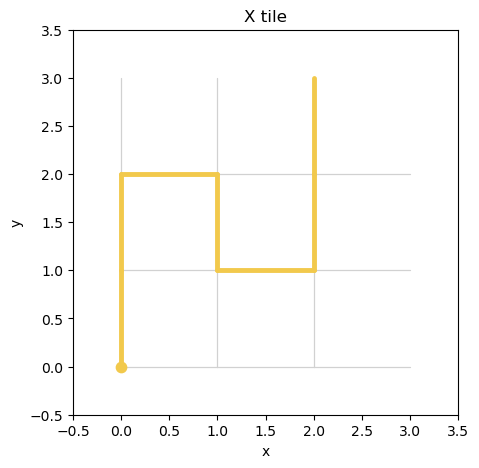

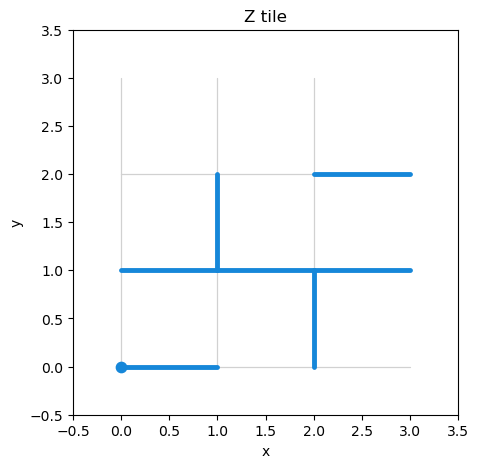

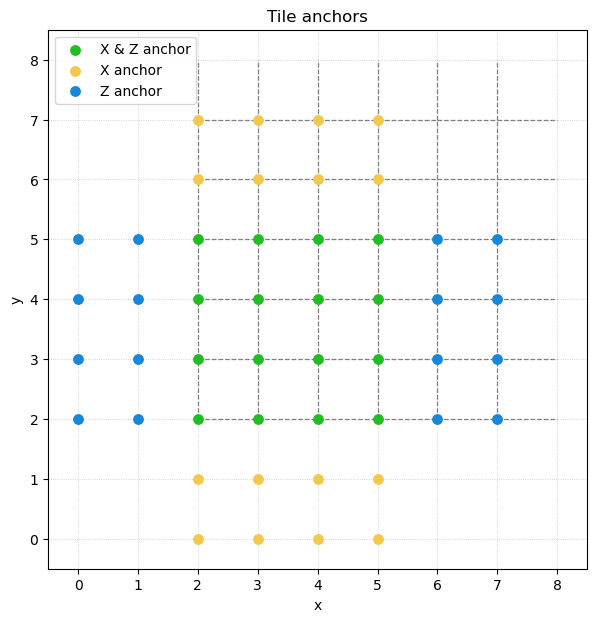

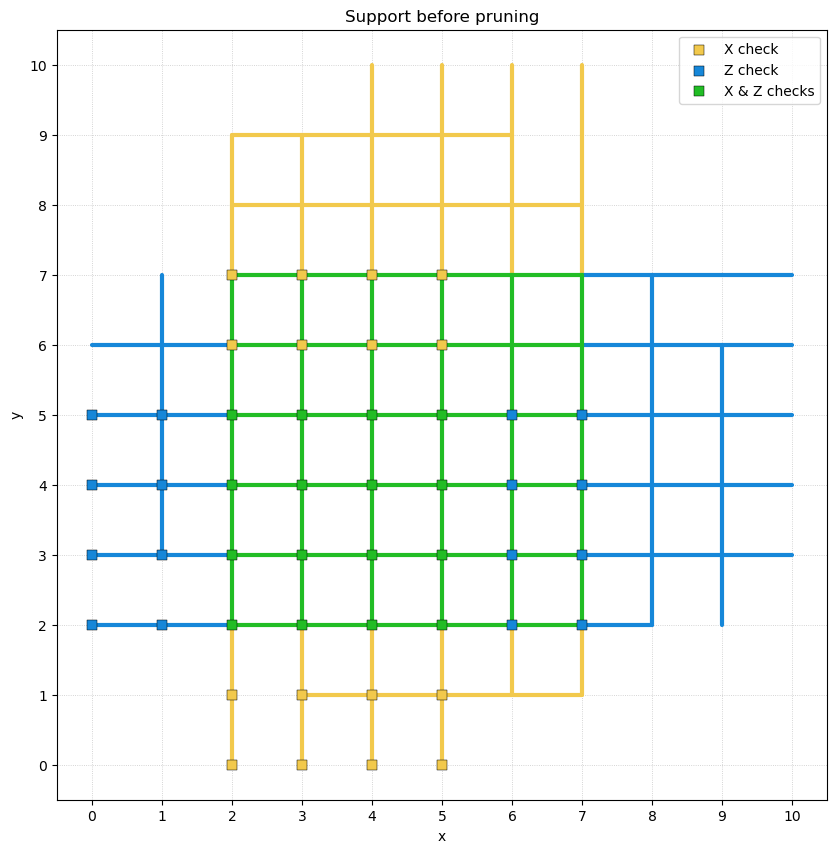

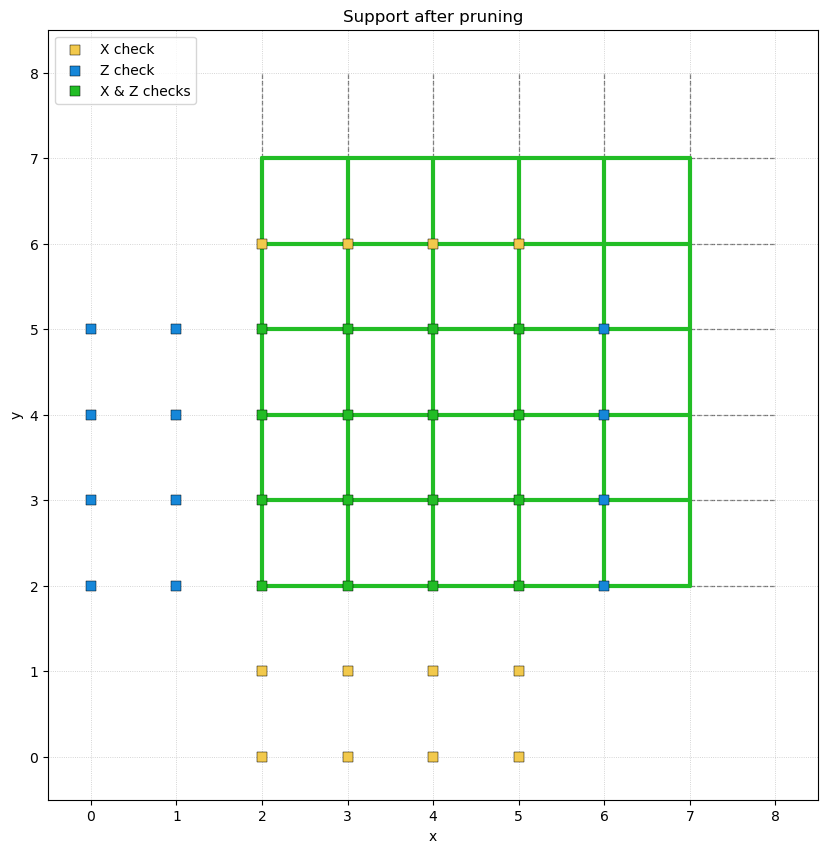

In [8]:
word = DirectionalWord("NNESENN")
code = DirTileCode(M=4, N=4, word=word)

print_visualization_summary(code)

plot_x_tile(code)
plt.show()

plot_z_tile(code)
plt.show()

plot_anchors(code)
plt.show()

plot_support_before_prune(code)
plt.show()

plot_support_after_prune(code)
plt.show()